# Import required packages

In [1]:
import numpy as np
import scanpy as sc
import yaml 
import os 
import anndata as ad
import matplotlib.pyplot as plt

# Figures and files setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_2"

### markers to showcase

In [6]:
phenotype_markers = ["ACTIN", "ARGINASE1", "CD3", "CD4", "CD8A", "CD11B", "CD11C", "CD15", "CD31", "CD38","CD68", "CD79A", "CD134", "CD138", "CD163", "CD274", "CYTOKERATIN", 'CYTOKERATIN5', 'CYTOKERATIN7', 'CYTOKERATIN14', 'CYTOKERATIN19', "HLAABC", "HLADR", "KI67", "MASTCELLTRYPTASE", "MRP14", "PODOPLANIN"] 

# Loading the main data

In [47]:
adata_unified = ad.read_h5ad(os.path.join(data_dir, "adata.h5ad"))
adata_unified.X = np.arcsinh(adata_unified.X)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_6168/1709052966.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


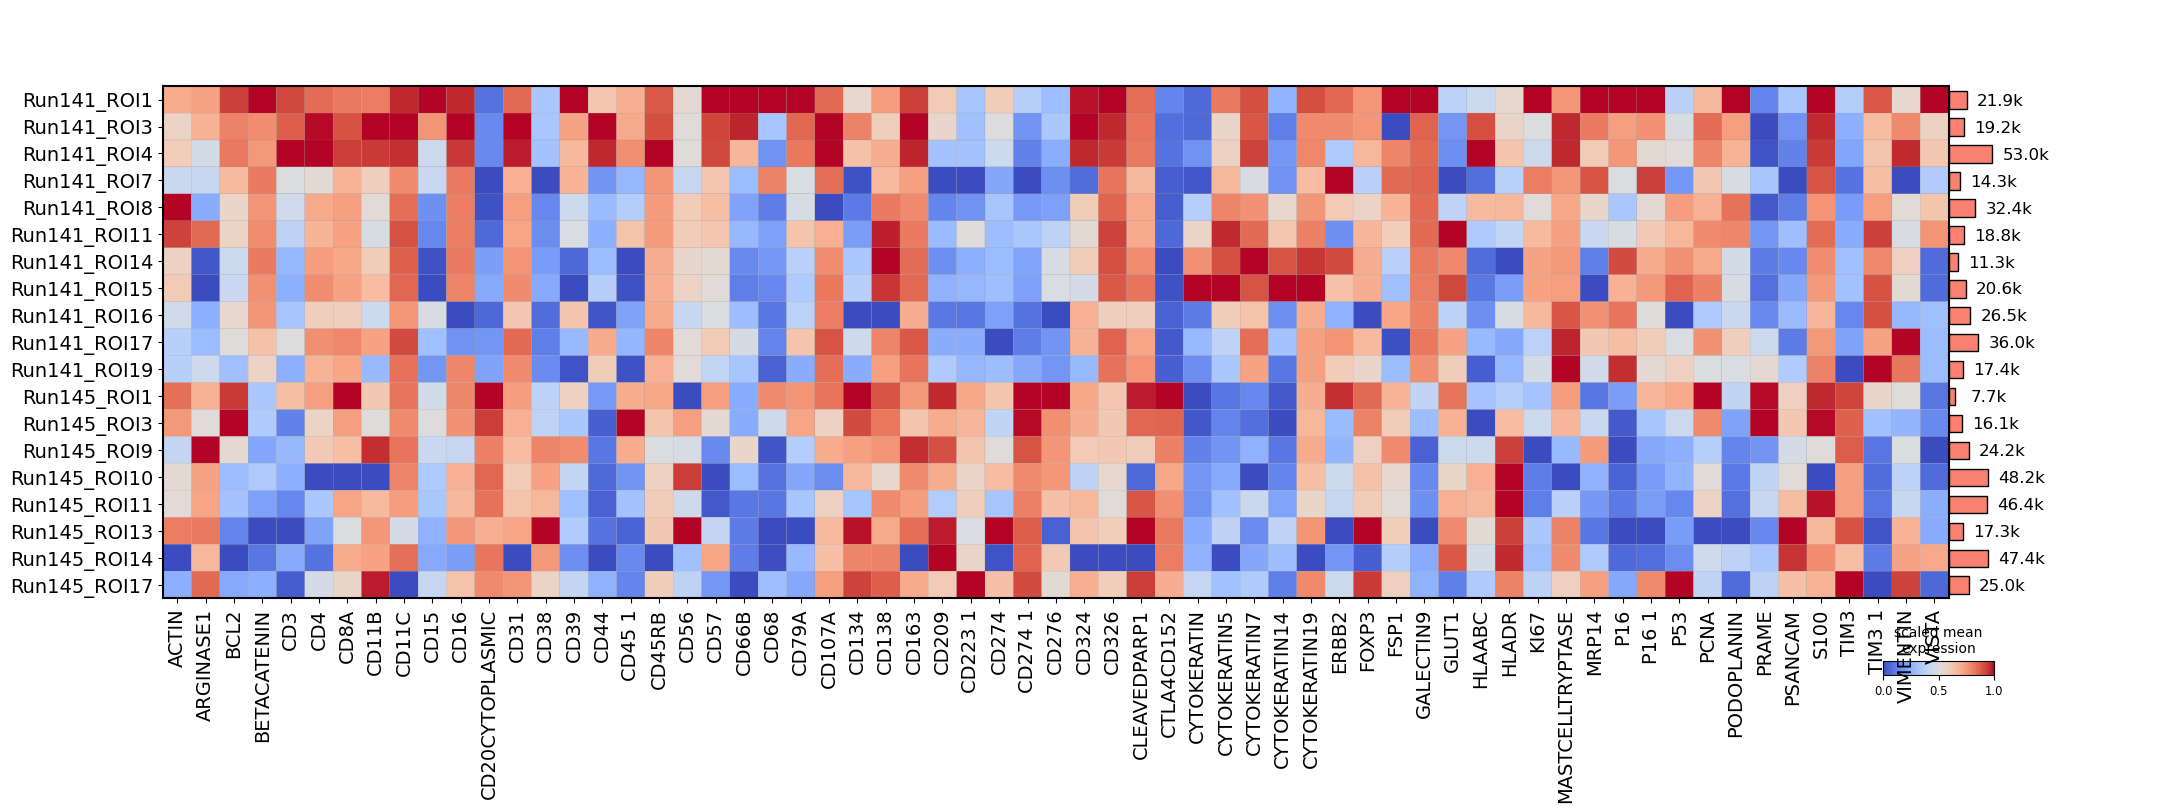

In [13]:
fig = sc.pl.matrixplot(
        adata_unified, 
        var_names=adata_unified.var_names, 
        groupby='exp_name', 
        cmap="coolwarm",
        standard_scale="var",
        layer="arcsinh",
        use_raw=False,
        show=False,
        return_fig=True,)
fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.06, cax_current_pos.y0 -0.1, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
# fig.savefig(os.path.join(results_dir, "phenotype_matrixplot_selected_markers.pdf"),bbox_inches='tight')

In [18]:
import seaborn as sns

In [52]:
adata_unified.obs.run

378930    145
66114     145
66113     145
66112     145
66111     145
         ... 
420571    141
420572    141
420573    141
420564    141
418979    141
Name: run, Length: 553331, dtype: category
Categories (4, int64): [92, 103, 141, 145]

<Axes: xlabel='ACTIN', ylabel='Density'>

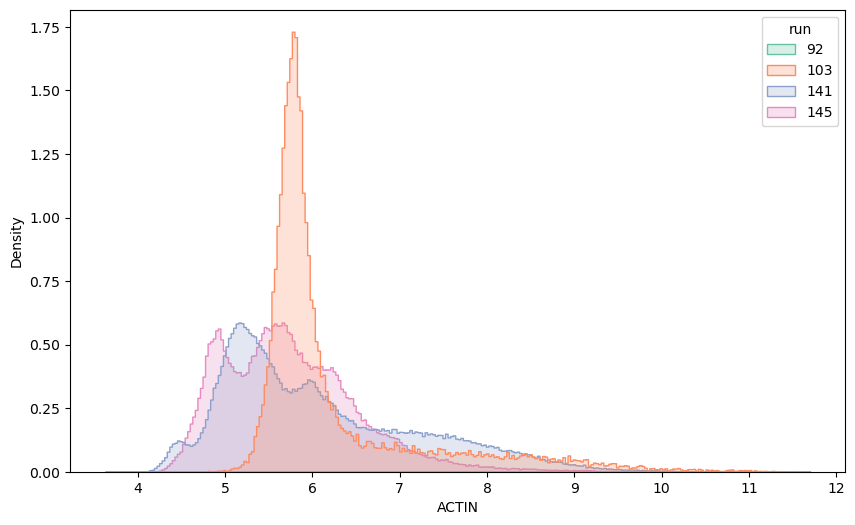

In [53]:
#compare the expression of ACTIN across different exp_name
data = adata_unified.to_df().reset_index()
data["run"] = adata_unified.obs["run"].values
#filter for only actin
data_select = data[["run", "ACTIN"]].copy()
#make boxplot now
fig = plt.figure(figsize=(10, 6))
#HISTOGRAM NOT FREAKIN BOXPLOT
#One histogram per exp_name
sns.histplot(data = data_select, x="ACTIN", hue="run", element="step", stat="density", common_norm=False, palette="Set2")

In [ ]:
#image folder of interest 
image_folder = "/Volumes/T7/Run141/ROI16/"
#load the image data
images = os.listdir(image_folder)
#look for first DAPI image
dapi = [img for img in images if "DAPI" in img][0]
cd28 = [img for img in images if "CD20Cytoplasmic" in img][0]
cd4 = [img for img in images if "CD4_" in img][0]
cd8 = [img for img in images if "CD8a_" in img][0]
mrp14 = [img for img in images if "MRP14" in img][0]
arg1 = [img for img in images if "Argi" in img][0]
cd15 = [img for img in images if "CD15_" in img][0]
cd204 = [img for img in images if "CD204" in img][0]
prame = [img for img in images if "PRAME" in img][0]

#load the images with tiffile 
import tifffile